# Comparaison — RF-DETR Nano (5-fold CV)
Modèle hors-Ultralytics. Réutilise **la config données et la construction des folds** de la comparaison
(mêmes tuiles, au même endroit), et le **même** `CSV_CV`. Données converties en COCO à partir de la
même liste de train (neg_ratio=3, listes figées partagées). Validation sur fold complet, fold5 réservé au test.

In [1]:
# 1. Installation (RF-DETR uniquement, pas d'Ultralytics)
!pip install -q "rfdetr[train,loggers]" pycocotools openpyxl wandb

import os, time, shutil, random, yaml, zipfile
import numpy as np, pandas as pd
from pathlib import Path


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 604.7/604.7 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.0/385.0 kB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 258.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 170.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# --- Connexion Drive ---
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# --- CONFIG DONNÉES (source des tuiles + variante labels_cell_20) ---
BASE_DIR  = Path("/content/drive/MyDrive/Emma/puceron_model_2026/puceron_model_E2026_3/data/tuile_viz02_640_128")
SPLIT_DIR = BASE_DIR / "split"
CELL_DIR  = Path("/content/drive/MyDrive/Emma/puceron_model_2026/puceron_model_E2026_2/data/cell/tuile_viz02_640_128_cell")

def V(csv, labels, extra_train=None):
    labels = Path(labels)
    if not labels.is_absolute():
        labels = BASE_DIR / labels
    variant = {"csv": Path(csv), "labels_dir": labels}
    if extra_train is not None:
        variant["extra_train"] = {"csv": Path(extra_train["csv"]),
                                  "labels_dir": Path(extra_train["labels_dir"]),
                                  "images_dir": Path(extra_train["images_dir"])}
    return variant

EXPERIMENT_NAME = "yolo_neg1"
VARIANTS = {
    "labels_cell_20": V(
        SPLIT_DIR / "split_assignments_all_background.csv", "labels_visible_20",
        extra_train={"csv":        CELL_DIR / "split" / "split_assignments.csv",
                     "labels_dir": CELL_DIR / "labels_cell_20",
                     "images_dir": CELL_DIR / "images_lookmatched3"}),
}
BASELINE_VARIANT = "labels_cell_20"
SEARCH_VARIANT   = BASELINE_VARIANT
USE_BACKGROUND   = True
MAIN_IMAGES_DIR  = BASE_DIR / "images"
BG_DIR = Path("/content/drive/MyDrive/Emma/puceron_model_2026/puceron_model_E2026_2/data/images_complete")
OUTPUT_ROOT = Path(f"/content/kfold_yolo/{EXPERIMENT_NAME}")
YAML_DIR    = Path(f"/content/yolo_yaml/{EXPERIMENT_NAME}"); YAML_DIR.mkdir(parents=True, exist_ok=True)
N_CV_FOLDS      = 5
TEST_FOLD_VALUE = 5
CLASS_NAMES     = {0: "Apterous_aphid", 1: "Alate_aphid"}
print("Config données OK | variante :", SEARCH_VARIANT, "| CV folds :", N_CV_FOLDS)

Config données OK | variante : labels_cell_20 | CV folds : 5


In [4]:
# ============================================================================
# CONSTRUCTION DES FOLDS À PARTIR DU CSV DE SPLIT (à exécuter APRÈS la config)
# Lit split_assignments_all_background.csv : chaque ligne -> son fold (colonne split).
#   label_file vide  -> tuile de FOND (image seule, pas de label)
#   label_file rempli -> PUCERON (image + label depuis labels_dir)
# Ajoute aussi le renfort "cell" (_extra_train, ajouté au train uniquement).
# ============================================================================
import zipfile, pandas as pd
from pathlib import Path

STAGE_LOCAL = Path("/content/stage_compare"); STAGE_LOCAL.mkdir(parents=True, exist_ok=True)
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def stage_dir(src):
    """Retourne un dossier LOCAL contenant les images de src.
       - si le dossier Drive est peuplé -> on l'utilise directement ;
       - sinon si <src>.zip existe -> on l'extrait UNE fois en local."""
    src = Path(src)
    if src.exists() and any(True for _ in src.iterdir()):
        return src
    zip_src = f"{src.parent}/tuile_viz02_640_128_background.zip"
    print(zip_src)
    local = STAGE_LOCAL / src.name
    if (local / ".done").exists():
        return local
    if zip_src.exists():
        local.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_src) as zf:
            zf.extractall(local)
        (local / ".done").write_text("ok")
        return local
    raise FileNotFoundError(f"Ni dossier peuplé ni archive .zip pour {src}")

def build_image_index(dirs):
    """Index {nom_fichier -> chemin} en fusionnant plusieurs dossiers sources."""
    idx = {}
    for d in dirs:
        base = stage_dir(d)
        for p in Path(base).rglob("*"):
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                idx.setdefault(p.name, p)      # premier trouvé gagne
    return idx

def _normalize_fold(v):
    """'fold3' -> 3 (tolère aussi un entier)."""
    return int(str(v).strip().lower().replace("fold", ""))

def _link(src, dst):
    if not dst.exists():
        try:
            dst.symlink_to(src)
        except FileExistsError:
            pass

def build_folds_from_csv():
    variant   = VARIANTS[BASELINE_VARIANT]
    df        = pd.read_csv(variant["csv"])
    labels_dir = Path(variant["labels_dir"])
    root      = OUTPUT_ROOT / SEARCH_VARIANT

    print("Indexation des images sources (pucerons + fonds)...")
    img_idx = build_image_index([MAIN_IMAGES_DIR, BG_DIR])
    print(f"  {len(img_idx)} images indexées.")

    for f in range(N_CV_FOLDS + 1):            # folds 0..5 (5 = test)
        (root / f"fold_{f}" / "images").mkdir(parents=True, exist_ok=True)
        (root / f"fold_{f}" / "labels").mkdir(parents=True, exist_ok=True)

    ok = miss = 0
    for name, lf, split in zip(df["image"], df["label_file"], df["split"]):
        fold = _normalize_fold(split)
        src_img = img_idx.get(name)
        if src_img is None:
            miss += 1; continue
        _link(src_img, root / f"fold_{fold}" / "images" / name)
        if isinstance(lf, str) and lf.strip():             # puceron -> label
            lsrc = labels_dir / lf
            if lsrc.exists():
                _link(lsrc, root / f"fold_{fold}" / "labels" / (Path(name).stem + ".txt"))
        ok += 1
    print(f"CSV principal : {ok} tuiles placées, {miss} images introuvables")

    # --- Renfort "cell" -> _extra_train (ajouté au TRAIN uniquement) ---
    ex = variant.get("extra_train")
    if ex:
        (root / "_extra_train" / "images").mkdir(parents=True, exist_ok=True)
        (root / "_extra_train" / "labels").mkdir(parents=True, exist_ok=True)
        ex_df   = pd.read_csv(ex["csv"])
        ex_imgs = build_image_index([ex["images_dir"]])
        ex_lbls = Path(ex["labels_dir"])
        n_ex = 0
        for name in ex_df["image"]:
            src_img = ex_imgs.get(name)
            if src_img is None:
                continue
            _link(src_img, root / "_extra_train" / "images" / name)
            lsrc = ex_lbls / (Path(name).stem + ".txt")
            if lsrc.exists():
                _link(lsrc, root / "_extra_train" / "labels" / (Path(name).stem + ".txt"))
            n_ex += 1
        print(f"_extra_train (cell) : {n_ex} images ajoutées (train uniquement)")

    return root

build_folds_from_csv()

# --- Vérification : compter pucerons/fonds réellement placés par fold ---
def _has_annotations(lbl):
    lbl = Path(lbl)
    return lbl.exists() and any(l.strip() for l in lbl.read_text().splitlines())

root = OUTPUT_ROOT / SEARCH_VARIANT
print("\nVérification (doit correspondre au CSV) :")
for f in range(N_CV_FOLDS + 1):
    imgs = list((root / f"fold_{f}" / "images").glob("*"))
    npuc = sum(1 for im in imgs if _has_annotations(root / f"fold_{f}" / "labels" / f"{im.stem}.txt"))
    print(f"  fold {f} : {len(imgs)} images ({npuc} pucerons, {len(imgs)-npuc} fonds)")


Indexation des images sources (pucerons + fonds)...
  2535 images indexées.
CSV principal : 1767 tuiles placées, 69849 images introuvables
_extra_train (cell) : 532 images ajoutées (train uniquement)

Vérification (doit correspondre au CSV) :
  fold 0 : 268 images (207 pucerons, 61 fonds)
  fold 1 : 370 images (250 pucerons, 120 fonds)
  fold 2 : 284 images (238 pucerons, 46 fonds)
  fold 3 : 269 images (216 pucerons, 53 fonds)
  fold 4 : 258 images (208 pucerons, 50 fonds)
  fold 5 : 318 images (228 pucerons, 90 fonds)


In [5]:
# --- CONFIG (sorties + réglages communs à la comparaison) ---
import os
SEED = 42
OUT_DIR = Path("/content/drive/MyDrive/Emma/puceron_model_2026/puceron_model_article/data")
OUT_DIR.mkdir(parents=True, exist_ok=True)
CSV_CV        = OUT_DIR / "comparaison_modeles_cv.csv"        # MÊME csv que la compare Ultralytics
SAVE_DIR      = OUT_DIR / "modeles";      SAVE_DIR.mkdir(parents=True, exist_ok=True)
SPLITS_FROZEN = OUT_DIR / "splits_figes"; SPLITS_FROZEN.mkdir(parents=True, exist_ok=True)
WANDB_PROJECT = "comparaison_pucerons_neg1"

COMPARE_EPOCHS = 30
BATCH          = 8      # RF-DETR (transformer) : petit batch pour éviter l'OOM T4
GRAD_ACCUM     = 4      # batch effectif = BATCH * GRAD_ACCUM = 32
IMGSZ          = 640
NEG_RATIO      = 3
CV_FOLDS       = list(range(N_CV_FOLDS))     # 0-4 ; fold5 réservé au test

def has_annotations(lbl):
    lbl = Path(lbl)
    return lbl.exists() and any(l.strip() for l in lbl.read_text().splitlines())
def _label_of(img_str):
    return Path(img_str.replace("/images/", "/labels/")).with_suffix(".txt")

print("Config OK | sorties :", OUT_DIR)

Config OK | sorties : /content/drive/MyDrive/Emma/puceron_model_2026/puceron_model_article/data


In [6]:
# --- Suivi W&B (login uniquement ; l'intégration se fait à l'appel train de RF-DETR) ---
import wandb
wandb.login()
os.environ["WANDB_PROJECT"] = WANDB_PROJECT
print("W&B prêt -> projet :", WANDB_PROJECT)
#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

/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: ERROR Invalid API key: API key must have 40+ characters, has 15.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


...

wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: dubrule1965 (equipe) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B prêt -> projet : comparaison_pucerons_neg1


In [7]:
# --- Liste des tuiles du train par fold (neg_ratio), avec liste figée partagée ---
# Produit la LISTE de chemins de tuiles du train (pas de yaml).
import random

def fold_train_paths(fold, neg_ratio):
    """train = 4 folds + _extra_train, négatifs sous-échantillonnés à neg_ratio×positifs.
    Réutilise/écrit la MÊME liste figée que la comparaison Ultralytics -> données identiques."""
    root = OUTPUT_ROOT / SEARCH_VARIANT
    txt_frozen = SPLITS_FROZEN / f"train_fold{fold}_neg{neg_ratio}.txt"
    if txt_frozen.exists():
        return [l for l in txt_frozen.read_text().splitlines() if l.strip()]
    pos, neg = [], []
    for i in range(N_CV_FOLDS):
        if i == fold: continue
        for img in sorted((root / f"fold_{i}" / "images").glob("*")):
            (pos if has_annotations(root/f"fold_{i}"/"labels"/f"{img.stem}.txt") else neg).append(str(img))
    ex = root / "_extra_train"
    if (ex / "images").exists():
        for img in sorted((ex / "images").glob("*")):
            (pos if has_annotations(ex/"labels"/f"{img.stem}.txt") else neg).append(str(img))
    random.seed(SEED + fold)
    negR = neg if len(neg) <= neg_ratio*len(pos) else random.sample(neg, neg_ratio*len(pos))
    lines = pos + negR
    txt_frozen.write_text("\n".join(lines))       # figé (partagé avec Ultralytics)
    return lines

print("fold_train_paths prêt (liste de tuiles, sans yaml Ultralytics).")

fold_train_paths prêt (liste de tuiles, sans yaml Ultralytics).


In [8]:
# --- Conversion COCO branchée sur fold_train_paths (mêmes tuiles que la compare) ---
import json, shutil
from pathlib import Path
from PIL import Image

CATEGORIES = [{"id": i + 1, "name": n} for i, n in CLASS_NAMES.items()]   # COCO 1-based

# Toutes les tuiles font TILE_SIZE x TILE_SIZE -> pas besoin d'ouvrir chaque image (évite les I/O Drive).
TILE_SIZE = 640
def _img_size(p):
    return TILE_SIZE, TILE_SIZE

def _yolo_boxes_px(lbl, W, H):
    out = []
    lbl = Path(lbl)
    if not lbl.exists(): return out
    for line in lbl.read_text().splitlines():
        s = line.split()
        if len(s) < 5: continue
        c, xc, yc, bw, bh = int(float(s[0])), *map(float, s[1:5])
        out.append((c + 1, (xc-bw/2)*W, (yc-bh/2)*H, bw*W, bh*H))
    return out

def _coco_from_paths(paths):
    images, anns, aid = [], [], 1
    paths = sorted(set(paths))
    for iid, ip in enumerate(paths, start=1):
        ip = Path(ip); W, H = _img_size(ip)
        images.append({"id": iid, "file_name": ip.name, "width": W, "height": H})
        for cat, x, y, w, h in _yolo_boxes_px(_label_of(str(ip)), W, H):
            anns.append({"id": aid, "image_id": iid, "category_id": cat,
                         "bbox": [round(x,2),round(y,2),round(w,2),round(h,2)],
                         "area": round(w*h,2), "iscrowd": 0, "segmentation": []})
            aid += 1
    return {"images": images, "annotations": anns, "categories": CATEGORIES}

def build_coco_fold(fold, neg_ratio):
    """Utilise fold_train_paths pour la liste EXACTE du train (neg_ratio) + le fold de val complet,
    puis produit l'arborescence RF-DETR train/valid/test avec symlinks + COCO JSON."""
    train_paths = fold_train_paths(fold, neg_ratio)          # mêmes données qu'Ultralytics
    npos = sum(1 for p in train_paths if has_annotations(_label_of(p)))
    nneg = len(train_paths) - npos
    root = OUTPUT_ROOT / SEARCH_VARIANT
    # val : fold complet
    val_paths = [str(p) for p in sorted((root / f"fold_{fold}" / "images").glob("*"))]

    ds = RFDETR_DATA / f"fold{fold}"
    # si le fold est DÉJÀ construit (COCO écrits), on ne refait rien -> gain de temps énorme
    if all((ds/sp/"_annotations.coco.json").exists() for sp in ("train","valid","test")):
        print(f"    fold{fold} déjà construit -> réutilisé", flush=True)
        return ds, npos, nneg
    if ds.exists(): shutil.rmtree(ds)
    for split, paths in [("train", train_paths), ("valid", val_paths), ("test", val_paths)]:
        d = ds / split; d.mkdir(parents=True, exist_ok=True)
        for p in paths:
            p = Path(p); dst = d / p.name
            if not dst.exists():
                try: dst.symlink_to(p)
                except FileExistsError: pass
        (d / "_annotations.coco.json").write_text(json.dumps(_coco_from_paths(paths)))
        print(f"    {split}: {len(paths)} images liées + COCO écrit", flush=True)
    return ds, npos, nneg

RFDETR_DATA = Path("/content/rfdetr_data"); RFDETR_DATA.mkdir(parents=True, exist_ok=True)
print("Conversion COCO prête (branchée sur fold_train_paths).")

Conversion COCO prête (branchée sur fold_train_paths).


In [9]:
# --- Entraînement RF-DETR Nano sur les 5 folds (mêmes données, mêmes sorties que la compare) ---
import time, numpy as np, pandas as pd, torch, wandb
from rfdetr import RFDETRNano
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

ncl = len(CLASS_NAMES); CLS = [CLASS_NAMES[i] for i in range(ncl)]
MODELE = "RF-DETR-N"
PATIENCE = 5   # early stopping RF-DETR (surveille le mAP val)

# Augmentation harmonisée avec le AUG de YOLO (SIMILAIRE, pas identique :
# mosaic/scale/translate de YOLO n'ont pas d'équivalent direct ; RF-DETR a son resize/crop interne).
AUG_RFDETR = {
    "HorizontalFlip": {"p": 0.5},                                   # fliplr=0.5
    "VerticalFlip":   {"p": 0.5},                                   # flipud=0.5
    "RandomBrightnessContrast": {"brightness_limit": 0.2,
                                 "contrast_limit": 0.2, "p": 0.5},  # hsv_v=0.2
    "ColorJitter": {"brightness": 0.0, "contrast": 0.0,
                    "saturation": 0.2, "hue": 0.0, "p": 0.5},       # hsv_s=0.2
}

def per_class_map(gt_json, dt_json, ncl):
    cocoGt = COCO(gt_json); cocoDt = cocoGt.loadRes(dt_json)
    out = {}
    for ci in range(ncl):
        e = COCOeval(cocoGt, cocoDt, "bbox"); e.params.catIds = [ci + 1]
        e.evaluate(); e.accumulate(); e.summarize()
        out[ci] = {"map5095": float(e.stats[0]), "map50": float(e.stats[1])}
    return out

def latency_cpu_ms(model, warmup=5, iters=30):
    from PIL import Image
    dummy = Image.fromarray((np.random.rand(IMGSZ, IMGSZ, 3)*255).astype("uint8"))
    try:
        for _ in range(warmup): model.predict(dummy)
        ts = []
        for _ in range(iters):
            t0 = time.perf_counter(); model.predict(dummy); ts.append((time.perf_counter()-t0)*1000)
        return float(np.mean(ts)), float(np.std(ts))
    except Exception as e:
        print("  latence CPU non mesurée:", e); return float("nan"), float("nan")

def predict_to_coco(model, images_dir, gt_json, out_json, conf=0.001):
    """Fait tourner model.predict sur chaque image de valid et écrit les détections au format COCO.
    Mappe file_name -> image_id via le COCO ground-truth. Robuste aux variations de l'objet résultat."""
    from PIL import Image as _Img
    gt = json.loads(Path(gt_json).read_text())
    name2id = {im["file_name"]: im["id"] for im in gt["images"]}
    dets = []
    for fn, iid in name2id.items():
        ip = Path(images_dir) / fn
        if not ip.exists():
            continue
        res = model.predict(_Img.open(ip).convert("RGB"))
        # RF-DETR renvoie généralement un objet avec .xyxy, .confidence, .class_id (style supervision)
        xyxy = getattr(res, "xyxy", None)
        conf_arr = getattr(res, "confidence", None)
        cls_arr = getattr(res, "class_id", None)
        if xyxy is None:   # variantes possibles : liste/tuple
            continue
        for k in range(len(xyxy)):
            x1, y1, x2, y2 = [float(v) for v in xyxy[k]]
            sc = float(conf_arr[k]) if conf_arr is not None else 1.0
            cid = int(cls_arr[k]) if cls_arr is not None else 0
            if sc < conf:
                continue
            dets.append({"image_id": iid, "category_id": cid + 1,   # RF-DETR 0-based -> COCO 1-based
                         "bbox": [x1, y1, x2 - x1, y2 - y1], "score": sc})
    Path(out_json).write_text(json.dumps(dets))
    return out_json

def tp_fp_fn_par_classe(gt_json, dt_json, ncl, conf_thr=0.25, iou_thr=0.5):
    """TP/FP/FN par classe (conf>=0.25, IoU>=0.5, alignés sur Ultralytics)."""
    gt = json.loads(Path(gt_json).read_text()); dt = json.loads(Path(dt_json).read_text())
    gt_by = {}; dt_by = {}
    for a in gt["annotations"]: gt_by.setdefault(a["image_id"], []).append((a["category_id"], *a["bbox"]))
    for d in dt: dt_by.setdefault(d["image_id"], []).append((d["category_id"], *d["bbox"], d["score"]))
    def iou(a, b):
        ax,ay,aw,ah=a; bx,by,bw,bh=b
        x1,y1=max(ax,bx),max(ay,by); x2,y2=min(ax+aw,bx+bw),min(ay+ah,by+bh)
        inter=max(0,x2-x1)*max(0,y2-y1); union=aw*ah+bw*bh-inter
        return inter/union if union>0 else 0.0
    tp=[0]*ncl; fp=[0]*ncl; fn=[0]*ncl
    for img in set(gt_by)|set(dt_by):
        for c in range(ncl):
            cat=c+1
            gts=[g[1:] for g in gt_by.get(img,[]) if g[0]==cat]
            dts=sorted([d for d in dt_by.get(img,[]) if d[0]==cat and d[5]>=conf_thr], key=lambda d:-d[5])
            matched=set()
            for d in dts:
                bi,bj=0.0,-1
                for j,g in enumerate(gts):
                    if j in matched: continue
                    v=iou(d[1:5],g)
                    if v>bi: bi,bj=v,j
                if bi>=iou_thr: tp[c]+=1; matched.add(bj)
                else: fp[c]+=1
            fn[c]+=len(gts)-len(matched)
    return tp,fp,fn

def model_taille(model):
    try:
        net=getattr(model,"model",model)
        params=sum(pp.numel() for pp in net.parameters())
        size=sum(pp.numel()*pp.element_size() for pp in net.parameters())/1e6
        return round(params/1e6,3), round(size,2)
    except Exception: return float("nan"), float("nan")

rows = pd.read_csv(CSV_CV).to_dict("records") if CSV_CV.exists() else []
done = {(r["modele"], int(r["fold"])) for r in rows if "modele" in r and "fold" in r}

for fold in CV_FOLDS:
    if (MODELE, fold) in done:
        print(f"  skip {MODELE} fold{fold}"); continue
    try:
        ds, npos, nneg = build_coco_fold(fold, NEG_RATIO)
        out = SAVE_DIR / f"{MODELE}_fold{fold}"
        model = RFDETRNano()
        t0 = time.time()
        base_kwargs = dict(dataset_dir=str(ds), epochs=COMPARE_EPOCHS,
                           batch_size=BATCH, grad_accum_steps=GRAD_ACCUM, output_dir=str(out),
                           early_stopping=True, early_stopping_patience=PATIENCE,
                           early_stopping_min_delta=0.001, early_stopping_use_ema=True,
                           aug_config=AUG_RFDETR)
        wb_run = None
        try:
            wb_run = wandb.init(project=WANDB_PROJECT, name=f"{MODELE}_fold{fold}",
                                reinit=True, config={"modele": MODELE, "fold": fold,
                                "epochs": COMPARE_EPOCHS, "batch": BATCH,
                                "grad_accum": GRAD_ACCUM, "neg_ratio": NEG_RATIO})
            print(f"        W&B run ouvert : {wb_run.name}", flush=True)
        except Exception as e:
            print("  W&B init impossible:", e, flush=True)
        try:
            model.train(**base_kwargs, wandb=True)
        except TypeError:
            model.train(**base_kwargs)
        if wb_run is not None:
            wb_run.finish()
        train_time = time.time() - t0

        gt = str(ds / "valid" / "_annotations.coco.json")
        dt_json = out / "val_predictions_coco.json"
        tp = fp = fn = [float("nan")]*ncl
        try:
            predict_to_coco(model, ds / "valid", gt, dt_json)
            per = per_class_map(gt, str(dt_json), ncl)
            tp, fp, fn = tp_fp_fn_par_classe(gt, str(dt_json), ncl)
        except Exception as e:
            print("  prédictions/éval COCO échouées:", e)
            per = {ci: {"map50": float("nan"), "map5095": float("nan")} for ci in range(ncl)}
        lat, lat_std = latency_cpu_ms(model)
        n_params_M, size_MB = model_taille(model)

        map50_macro   = float(np.nanmean([per[ci]["map50"]   for ci in range(ncl)]))
        map5095_macro = float(np.nanmean([per[ci]["map5095"] for ci in range(ncl)]))
        row = {"modele": MODELE, "fold": fold,
               "map50_macro": round(map50_macro,4), "map5095_macro": round(map5095_macro,4),
               "n_pucerons_train": npos, "n_fonds_train": nneg,
               "train_time_s": round(train_time,1),
               "latency_cpu_ms": round(lat,3), "latency_std_ms": round(lat_std,3),
               "n_params_M": n_params_M, "size_MB": size_MB}
        for ci, nm in enumerate(CLS):
            pr = tp[ci]/(tp[ci]+fp[ci]) if (tp[ci]+fp[ci]) else 0.0
            rc = tp[ci]/(tp[ci]+fn[ci]) if (tp[ci]+fn[ci]) else 0.0
            f1 = 2*pr*rc/(pr+rc) if (pr+rc) else 0.0
            row[f"{nm}_map50"]   = round(per[ci]["map50"],4)
            row[f"{nm}_map5095"] = round(per[ci]["map5095"],4)
            row[f"{nm}_P"]=round(pr,4); row[f"{nm}_R"]=round(rc,4); row[f"{nm}_F1"]=round(f1,4)
            row[f"{nm}_TP"]=tp[ci]; row[f"{nm}_FP"]=fp[ci]; row[f"{nm}_FN"]=fn[ci]
        rows.append(row); pd.DataFrame(rows).to_csv(CSV_CV, index=False)
        print(f"  OK {MODELE} fold{fold} : puc/fond train={npos}/{nneg} | {row}")
    except Exception as e:
        print(f"  ERREUR {MODELE} fold{fold} : {type(e).__name__}: {e}"); continue

print("Terminé ->", CSV_CV)

Val (ema) (Epoch 10/30) — Overall Metrics            
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃           mAP            ┃  mAR   ┃         F1 sweep         ┃
┡━━━━━━━━┯━━━━━━━━┯━━━━━━━━╇━━━━━━━━╇━━━━━━━━┯━━━━━━━━┯━━━━━━━━┩
│ 50:95  │   50   │   75   │  @500  │   F1   │  Prec  │ Recall │
├────────┼────────┼────────┼────────┼────────┼────────┼────────┤
│ 0.3800 │ 0.6782 │ 0.3858 │ 0.6315 │ 0.6612 │ 0.9283 │ 0.5687 │
└────────┴────────┴────────┴────────┴────────┴────────┴────────┘

INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric __rfdetr_effective_map__ did not improve in the last 5 records. Best score: 0.398. Signaling Trainer to stop.


[2026-09-18 05:17:10] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.0000, ema=0.3975)


epoch,▁▁▁▂▂▂▃▃▃▃▃▃▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇███
train/cardinality_error,▁▇▇▇█▇▇███
train/cardinality_error_0,▁▅▇▇█▇▇███
train/cardinality_error_enc,▁▆▇▇██████
train/class_error,█▂▁▁▁▁▁▁▁▁
train/loss,█▄▃▃▂▂▂▁▁▁
train/loss_bbox,█▄▃▃▂▂▃▂▂▁
train/loss_bbox_aux,█▄▃▃▂▂▃▁▂▁
train/loss_ce,█▄▃▂▂▂▂▁▁▁
train/loss_ce_aux,█▄▃▂▂▂▂▁▁▁
+17,...


[2026-09-18 05:17:18] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.inference(dtype=torch.float16).


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.02s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.471
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.750
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.564
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.270
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.526
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.384
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.529
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

## Hyperparamètres, augmentations (CSV) et visualisation de leur effet

In [10]:
# --- Enregistrer hyperparamètres + augmentations dans des CSV ---
import datetime, pandas as pd
stamp = datetime.datetime.now().strftime("%Y-%m-%d")
hp = {"date": stamp, "modele": "RF-DETR-N", "backbone": "DINOv2 Nano", "format": "COCO",
      "epochs": COMPARE_EPOCHS, "batch_size": BATCH, "grad_accum_steps": GRAD_ACCUM,
      "batch_effectif": BATCH*GRAD_ACCUM, "resolution": IMGSZ,
      "optimizer": "AdamW (défaut RF-DETR)", "lr": "défaut RF-DETR (~1e-4)", "ema": True,
      "neg_ratio_train": NEG_RATIO, "validation": "fold complet",
      "early_stopping": True, "patience": PATIENCE, "min_delta": 0.001, "seed": SEED}
pd.DataFrame([hp]).to_csv(OUT_DIR/"hyperparametres_rfdetr.csv", index=False)
aug_rows = [{"date": stamp, "modele": "RF-DETR-N", "transform": n,
             **{f"param_{k}": v for k,v in kw.items()}} for n,kw in AUG_RFDETR.items()]
pd.DataFrame(aug_rows).to_csv(OUT_DIR/"augmentations_rfdetr.csv", index=False)
print("CSV écrits :", OUT_DIR/"hyperparametres_rfdetr.csv", "et augmentations_rfdetr.csv")
print(pd.DataFrame(aug_rows).to_string(index=False))

CSV écrits : /content/drive/MyDrive/Emma/puceron_model_2026/puceron_model_article/data/hyperparametres_rfdetr.csv et augmentations_rfdetr.csv
      date    modele                transform  param_p  param_brightness_limit  param_contrast_limit  param_brightness  param_contrast  param_saturation  param_hue
2026-09-18 RF-DETR-N           HorizontalFlip      0.5                     NaN                   NaN               NaN             NaN               NaN        NaN
2026-09-18 RF-DETR-N             VerticalFlip      0.5                     NaN                   NaN               NaN             NaN               NaN        NaN
2026-09-18 RF-DETR-N RandomBrightnessContrast      0.5                     0.2                   0.2               NaN             NaN               NaN        NaN
2026-09-18 RF-DETR-N              ColorJitter      0.5                     NaN                   NaN               0.0             0.0               0.2        0.0


    fold0 déjà construit -> réutilisé


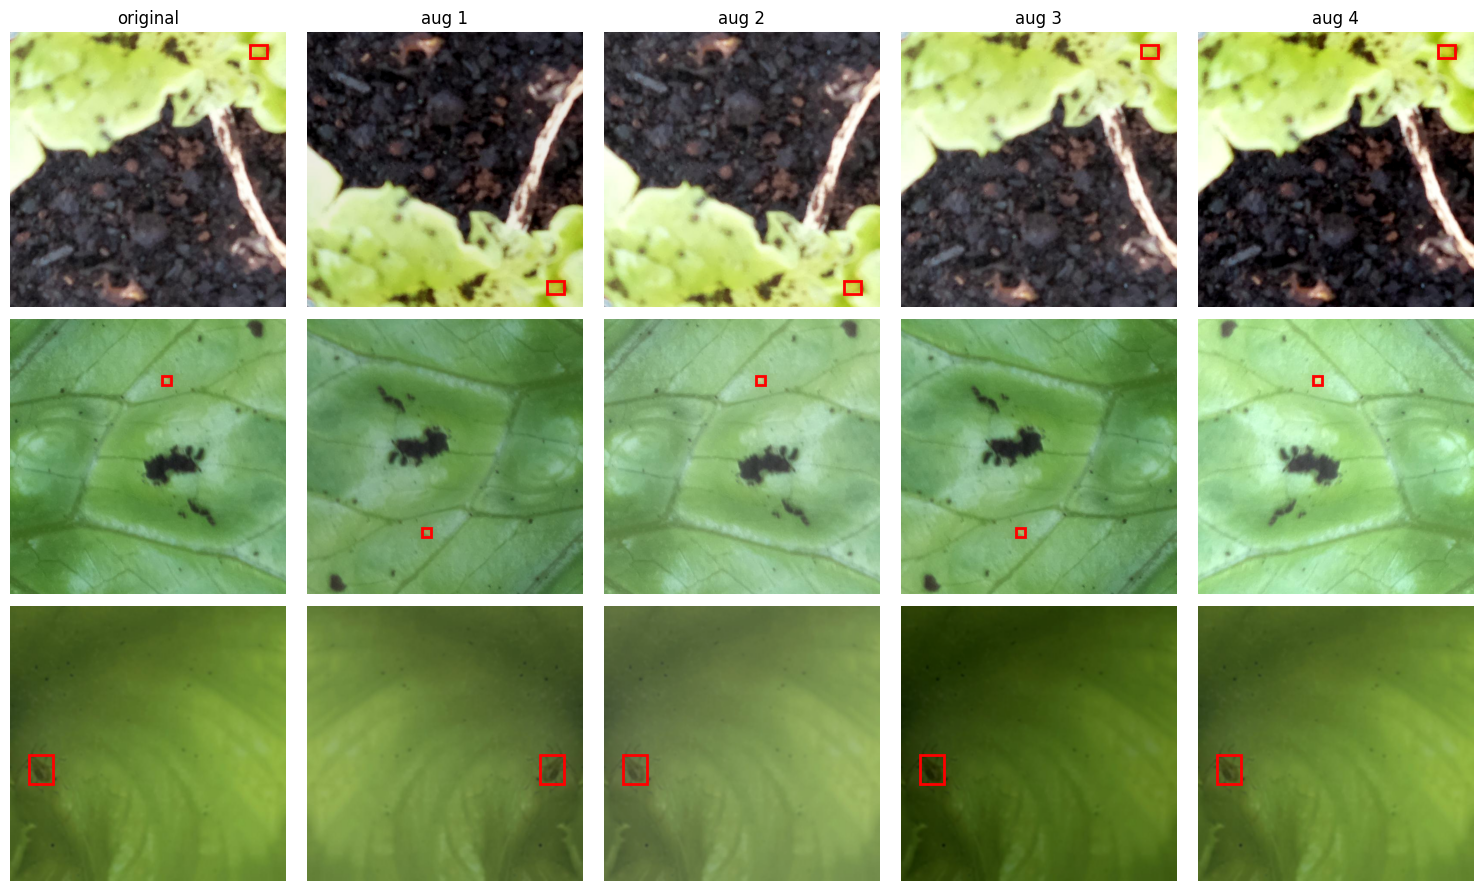

In [11]:
# --- Visualiser l'effet des augmentations (mêmes transforms que l'entraînement) ---
import json, random, numpy as np
import matplotlib.pyplot as plt, matplotlib.patches as patches
from PIL import Image
import albumentations as A

def _pipeline(aug):
    tfs=[]
    for name,kw in aug.items():
        cls=getattr(A,name,None)
        if cls is None: print("  (transform inconnu ignoré:",name,")"); continue
        tfs.append(cls(**kw))
    return A.Compose(tfs, bbox_params=A.BboxParams(format="coco", label_fields=["cats"]))

def visualiser_augmentations(fold=0, n_images=3, n_aug=4):
    ds = RFDETR_DATA/f"fold{fold}"/"train"
    coco = json.loads((ds/"_annotations.coco.json").read_text())
    par={}
    for a in coco["annotations"]: par.setdefault(a["image_id"],[]).append(a)
    avec=[im for im in coco["images"] if im["id"] in par]
    random.seed(0); choix=random.sample(avec, min(n_images,len(avec)))
    pipe=_pipeline(AUG_RFDETR); coul={1:"red",2:"yellow"}
    fig,axes=plt.subplots(len(choix),n_aug+1,figsize=(3*(n_aug+1),3*len(choix)))
    if len(choix)==1: axes=axes[None,:]
    for r,im in enumerate(choix):
        img=np.array(Image.open(ds/im["file_name"]).convert("RGB"))
        bb=[a["bbox"] for a in par[im["id"]]]; ca=[a["category_id"] for a in par[im["id"]]]
        ax=axes[r][0]; ax.imshow(img)
        for b,c in zip(bb,ca): ax.add_patch(patches.Rectangle((b[0],b[1]),b[2],b[3],fill=False,edgecolor=coul.get(c,"lime"),lw=2))
        ax.set_title("original" if r==0 else ""); ax.axis("off")
        for k in range(1,n_aug+1):
            o=pipe(image=img,bboxes=bb,cats=ca)
            ax=axes[r][k]; ax.imshow(o["image"])
            for b,c in zip(o["bboxes"],o["cats"]): ax.add_patch(patches.Rectangle((b[0],b[1]),b[2],b[3],fill=False,edgecolor=coul.get(c,"lime"),lw=2))
            ax.set_title(f"aug {k}" if r==0 else ""); ax.axis("off")
    plt.tight_layout(); plt.show()

build_coco_fold(0, NEG_RATIO)              # s'assure que fold0 existe
visualiser_augmentations(fold=0, n_images=3, n_aug=4)